In [4]:

!pip install ultralytics


from ultralytics import YOLO
import shutil
import os


model = YOLO('yolov8m.pt')
results = model.train(
    data='/kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    cache=True,
    amp=True,
    project="FacialDisease",
    name="YOLOv8m"
)


shutil.copy(
    '/kaggle/working/FacialDisease/YOLOv8m/weights/best.pt',
    '/kaggle/working/best.pt'
)
print("Model saved! ✅")

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8m, nbs=64, nms=False, ops

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/FacialDisease/YOLOv8m/weights/best.pt'

In [10]:
!cp /kaggle/working/runs/detect/FacialDisease/YOLOv8m/weights/best.pt /kaggle/working/best.pt


image 1/1355 /kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images/Acne_0_0002_jpg.rf.fe207eded1f2a5a7443163908cbe649a.jpg: 640x640 1 Acne, 36.8ms
image 2/1355 /kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images/Acne_0_0005_jpg.rf.86011207b3e3e9482c4316a516195286.jpg: 640x640 1 Acne, 36.9ms
image 3/1355 /kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images/Acne_0_0030_jpg.rf.558251465d860771a85f2c516c5a1ab1.jpg: 640x640 1 Acne, 35.8ms
image 4/1355 /kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images/Acne_0_0038_jpg.rf.dc2f92264c17cf01b5a1da124555262a.jpg: 640x640 1 Acne, 35.3ms
image 5/1355 /kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images/Acne_0_0040_jpg.rf.b65c63b02ff58cc5fd3f43988295254e.jpg: 640x640 1 Acne, 35.3ms
image 6/1

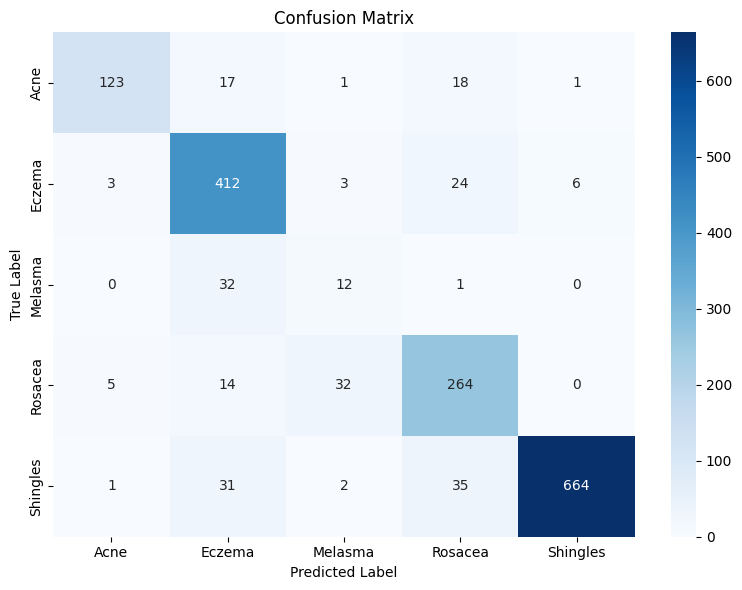


Done!


In [11]:
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = YOLO('/kaggle/working/runs/detect/FacialDisease/YOLOv8m/weights/best.pt')

class_names = ['Acne', 'Eczema', 'Melasma', 'Rosacea', 'Shingles']

y_true = []
y_pred = []

for result in model.predict(
    source='/kaggle/input/datasets/uqbanisar143/disease-dataset/5 Datasets Skin Diseases 2.v2-v2.yolov8/valid/images',
    stream=True
):
    boxes = result.boxes
    if boxes is not None:
        for box in boxes:
            y_pred.append(int(box.cls.item()))
            label_path = result.path.replace('images', 'labels').replace('.jpg', '.txt')
            try:
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    if lines:
                        y_true.append(int(lines[0].split()[0]))
            except:
                y_true.append(int(box.cls.item()))

min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png')
plt.show()
print("\nDone!")

In [12]:
from sklearn.metrics import accuracy_score
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

Overall Accuracy: 86.71%
